In [2]:
import numpy as np
import random
import torch
import torch.optim as optim
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import time

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [4]:
hidden_state=64
num_of_layers=1
lr=0.001
batch_size=64
seed=42
sequence_length=[10,25,50,100,200,500]
epochs=50
trials=3
input_size=2
output_size=1

results = {
    "RNN": {T: [] for T in sequence_length},
    "LSTM": {T: [] for T in sequence_length},
    "GRU": {T: [] for T in sequence_length}
}

training_times = {
    "RNN": {T: [] for T in sequence_length},
    "LSTM": {T: [] for T in sequence_length},
    "GRU": {T: [] for T in sequence_length}
}

grad_norms = {
    "RNN": {T: [] for T in sequence_length},
    "LSTM": {T: [] for T in sequence_length},
    "GRU": {T: [] for T in sequence_length}
}

train_losses = {
    "RNN": {T: [] for T in sequence_length},
    "LSTM": {T: [] for T in sequence_length},
    "GRU": {T: [] for T in sequence_length}
}

In [5]:
class RNN(nn.Module):
    def __init__(self,input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        self.rnn=nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True            
            )
        self.fc=nn.Linear(hidden_size, num_classes)

    def forward(self,x):
        out, h_n=self.rnn(x)
        out=out[:,-1,:]
        out=self.fc(out)
        return out
    
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        self.lstm=nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True            
            )
        self.fc=nn.Linear(hidden_size, num_classes)
    
    def forward(self,x):
        out, (h_n,c_n)=self.lstm(x)
        out=out[:,-1,:]
        out=self.fc(out)
        return out
    
class GRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        self.gru=nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True            
            )
        self.fc=nn.Linear(hidden_size, num_classes)
    
    def forward(self,x):
        out, h_n=self.gru(x)
        out=out[:,-1,:]
        out=self.fc(out)
        return out

In [6]:
def generate_adding_problem(num_samples, seq_len):
    x_values = np.random.uniform(0, 1, (num_samples, seq_len))
    x_mask = np.zeros((num_samples, seq_len))

    for i in range(num_samples):
        indices = np.random.choice(seq_len, size=2, replace=False)
        x_mask[i, indices] = 1.0
    X = np.stack([x_values, x_mask], axis=-1)
    y = np.sum(x_values * x_mask, axis=1, keepdims=True)
    return X.astype(np.float32), y.astype(np.float32)

models_dict = {
    "RNN": RNN(input_size, hidden_state, num_of_layers, output_size).to(device),
    "LSTM": LSTM(input_size, hidden_state, num_of_layers, output_size).to(device),
    "GRU": GRU(input_size, hidden_state, num_of_layers, output_size).to(device)
}

optimizers_dict = {
    "RNN": optim.Adam(models_dict["RNN"].parameters(), lr=lr),
    "LSTM": optim.Adam(models_dict["LSTM"].parameters(), lr=lr),
    "GRU": optim.Adam(models_dict["GRU"].parameters(), lr=lr)
}

In [7]:
criterion=nn.MSELoss()
for T in sequence_length:
    print(f"\nStarting T={T}...")
    X_train, y_train = generate_adding_problem(10000, T)
    X_test, y_test = generate_adding_problem(2000, T)

    X_train = torch.tensor(X_train)
    y_train = torch.tensor(y_train)
    X_test = torch.tensor(X_test)
    y_test = torch.tensor(y_test)

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    for trial in range(trials):
        torch.manual_seed(seed+trial)
        np.random.seed(seed+trial)
        random.seed(seed+trial)
        torch.cuda.empty_cache()  # Clean GPU memory

        for model_name in ["RNN", "LSTM", "GRU"]:
            # Reinitialize model and optimizer per trial
            if model_name == "RNN":
                model = RNN(input_size, hidden_state, num_of_layers, output_size).to(device)
            elif model_name == "LSTM":
                model = LSTM(input_size, hidden_state, num_of_layers, output_size).to(device)
            else:
                model = GRU(input_size, hidden_state, num_of_layers, output_size).to(device)

            optimizer = optim.Adam(model.parameters(), lr=lr)
            model.train()

            epoch_times = []
            losses = []
            grad_norm_per_epoch = []

            for epoch in range(epochs):
                start_time = time.time()
                epoch_loss = 0

                for x_batch, y_batch in train_loader:
                    x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                    optimizer.zero_grad()
                    output = model(x_batch)
                    loss = criterion(output, y_batch)
                    loss.backward()

                    # Gradient norm
                    total_norm = 0
                    for p in model.parameters():
                        if p.grad is not None:
                            total_norm += p.grad.data.norm(2).item()**2
                    grad_norm_per_epoch.append(total_norm**0.5)

                    optimizer.step()
                    epoch_loss += loss.item()

                epoch_times.append(time.time() - start_time)
                losses.append(epoch_loss / len(train_loader))

            model.eval()
            test_loss = 0
            with torch.no_grad():
                for x_batch, y_batch in test_loader:
                    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                    output = model(x_batch)
                    test_loss += criterion(output, y_batch).item()
            test_loss /= len(test_loader)

            results[model_name][T].append(test_loss)
            training_times[model_name][T].append(np.mean(epoch_times))
            grad_norms[model_name][T].append(np.mean(grad_norm_per_epoch))
            train_losses[model_name][T].append(losses)
            print(f"  T={T} | Trial {trial+1} | {model_name} | Test MSE: {test_loss:.4f}")

param_counts = {model_name: sum(p.numel() for p in models_dict[model_name].parameters()) 
                for model_name in ["RNN","LSTM","GRU"]}
print(param_counts)


Starting T=10...
  T=10 | Trial 1 | RNN | Test MSE: 0.0032
  T=10 | Trial 1 | LSTM | Test MSE: 0.0001
  T=10 | Trial 1 | GRU | Test MSE: 0.0001
  T=10 | Trial 2 | RNN | Test MSE: 0.0007
  T=10 | Trial 2 | LSTM | Test MSE: 0.0002
  T=10 | Trial 2 | GRU | Test MSE: 0.0000
  T=10 | Trial 3 | RNN | Test MSE: 0.0027
  T=10 | Trial 3 | LSTM | Test MSE: 0.0001
  T=10 | Trial 3 | GRU | Test MSE: 0.0000

Starting T=25...
  T=25 | Trial 1 | RNN | Test MSE: 0.0060
  T=25 | Trial 1 | LSTM | Test MSE: 0.0001
  T=25 | Trial 1 | GRU | Test MSE: 0.0001
  T=25 | Trial 2 | RNN | Test MSE: 0.0074
  T=25 | Trial 2 | LSTM | Test MSE: 0.0002
  T=25 | Trial 2 | GRU | Test MSE: 0.0001
  T=25 | Trial 3 | RNN | Test MSE: 0.0139
  T=25 | Trial 3 | LSTM | Test MSE: 0.0001
  T=25 | Trial 3 | GRU | Test MSE: 0.0001

Starting T=50...
  T=50 | Trial 1 | RNN | Test MSE: 0.1560
  T=50 | Trial 1 | LSTM | Test MSE: 0.0019
  T=50 | Trial 1 | GRU | Test MSE: 0.0001
  T=50 | Trial 2 | RNN | Test MSE: 0.0237
  T=50 | Trial 

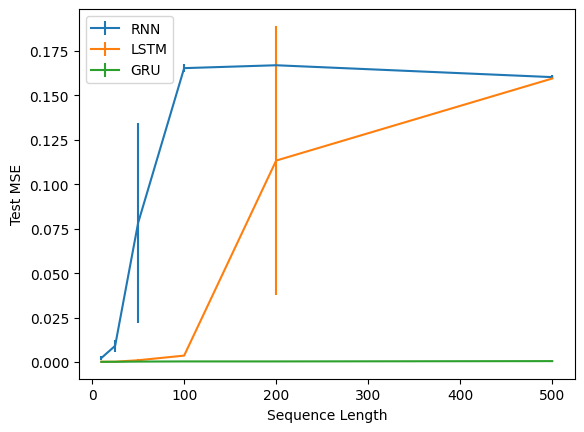

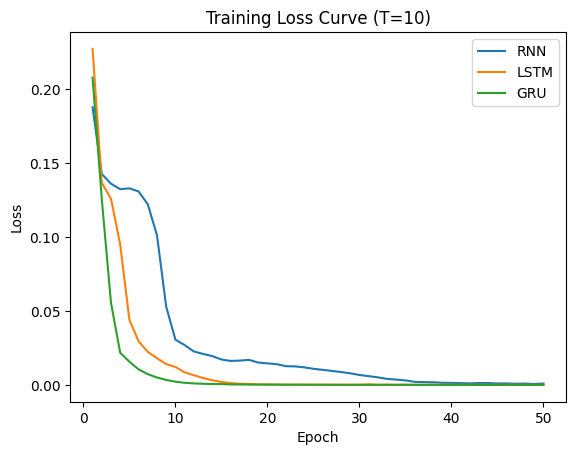

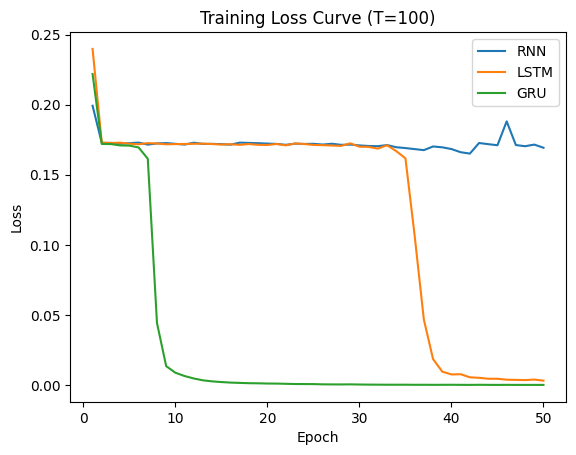

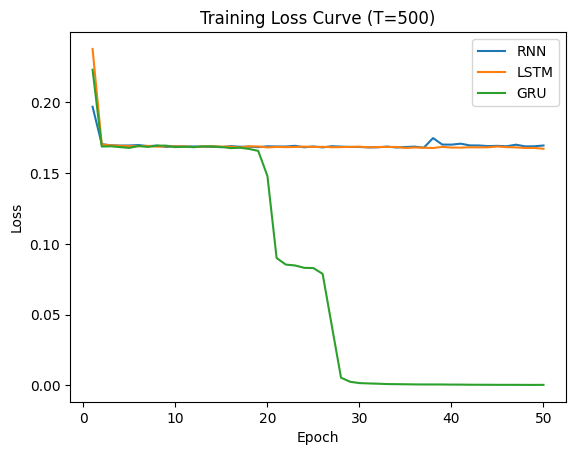

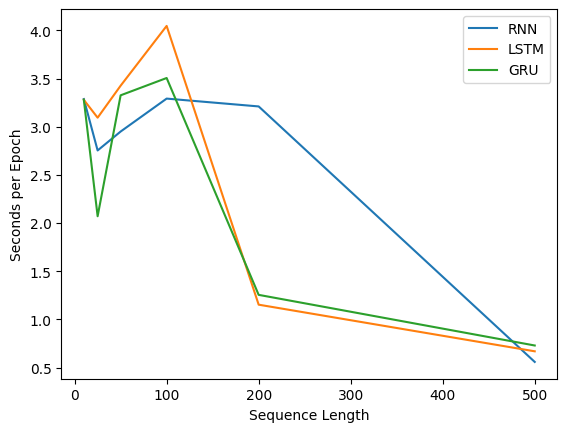

In [8]:
plt.figure()
for model_name in ["RNN","LSTM","GRU"]:
    means = [np.mean(results[model_name][T]) for T in sequence_length]
    stds = [np.std(results[model_name][T]) for T in sequence_length]
    plt.errorbar(sequence_length, means, yerr=stds, label=model_name)
plt.xlabel("Sequence Length")
plt.ylabel("Test MSE")
plt.legend()
plt.show()
for T in [10, 100, 500]:
    plt.figure()
    for model_name in ["RNN","LSTM","GRU"]:
        losses = train_losses[model_name][T][0]  
        plt.plot(range(1, epochs+1), losses, label=model_name)
    plt.title(f"Training Loss Curve (T={T})")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
plt.figure()
for model_name in ["RNN","LSTM","GRU"]:
    times = [np.mean(training_times[model_name][T]) for T in sequence_length]
    plt.plot(sequence_length, times, label=model_name)
plt.xlabel("Sequence Length")
plt.ylabel("Seconds per Epoch")
plt.legend()
plt.show()

In [ ]:
print("TABLE 2: Performance vs. Sequence Length")
print("Sequence Length | RNN | LSTM | GRU")

for T in sequence_length:
    rnn_mean = np.mean(results["RNN"][T])
    rnn_std = np.std(results["RNN"][T])

    lstm_mean = np.mean(results["LSTM"][T])
    lstm_std = np.std(results["LSTM"][T])

    gru_mean = np.mean(results["GRU"][T])
    gru_std = np.std(results["GRU"][T])

    print(f"{T:<15} | "
          f"{rnn_mean:.4f} ± {rnn_std:.4f} | "
          f"{lstm_mean:.4f} ± {lstm_std:.4f} | "
          f"{gru_mean:.4f} ± {gru_std:.4f}")

NameError: name 'results' is not defined